<a href="https://colab.research.google.com/github/lukasz23g/Machine-Learning-2026/blob/main/Lab13_images/ML_project_v0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/lukasz23g/Machine-Learning-2026/blob/main/Lab13_images/ML_project_v0.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning - Final Project
## Project author: Łukasz Grzegrzółka

#### Project from: Lab 12 - Towards Self-Attention (*pl. Samoatencja*), original notebook author: Szymon Nowakowski


# Position-Aware Attention Post-Processing Variant

One will note that in the last attention example we averaged attention results like this:

```python
  # Attend and pool original features using attention weights
  attended = self.attention(features)              # size: batch, words, d_v
  pooled = attended.mean(dim = -2)                 # size: batch, d_v  # average across words

  output = self.classifier(F.relu(pooled))         # size: batch, 1     # Note, that we add a nonlinearity to avoid collapsing two subsequent linear operators: V and then the classifier layer
```

This is well-suited for tasks that do not require positional specificity, such as global classification.

A position-aware variant avoids collapsing across the sequence too early and retains the positional structure throught the classificator:

```python
  # Attend and keep positional information
  attended = self.attention(features)              # size: batch, words, d_v
  tokenwise = self.classifier(F.relu(attended))    # size: batch, words, hidden/1/...(other)
```

Here, the classifier is applied token-wise, and the output retains the sequence dimension for further analysis.

For example, if the task is to identify which word is most relevant, we can set the output dimension to 1, apply softmax, and compute a soft-argmax:

```python
  # Attend and predict importance per word
  attended = self.attention(features)                      # size: batch, words, d_v
  tokenwise = self.classifier(F.relu(attended))            # size: batch, words, 1
  logits   = tokenwise.squeeze(-1)                         # size: batch, words
  probs    = logits.softmax(dim=-1)                        # size: batch, words

  # Differentiable soft-argmax over positions
  return soft_argmax_from_prob(probs)                      # size: batch
```


with:
```python
def soft_argmax_from_prob(prob, dim=-1):
    """
    Computes soft-argmax given a probability distribution over positions.

    Args:
        prob (Tensor): Probability distribution over positions (e.g., after softmax)
        dim (int): Dimension along which to compute the expected index

    Returns:
        Tensor: Expected index (float), differentiable
    """
    positions = torch.arange(prob.size(dim), device=prob.device, dtype=prob.dtype)
    return torch.sum(prob * positions, dim=dim)

```

## Example of *soft argmax*

Suppose we are working with a sequence of 4 tokens (instead of, say, 128), and we wish to identify which token is most relevant.  
Assume that we have applied attention and a token-wise classifier that produces the following unnormalized scores (logits):

$$
\text{logits} = [1.5,\ 2.0,\ 4.0,\ -1.0]
$$

After applying softmax, we obtain the following probabilities over the 4 positions:

$$
\text{probs} = \text{softmax}([1.5,\ 2.0,\ 4.0,\ -1.0]) \approx [0.07,\ 0.12,\ 0.79,\ 0.02]
$$

Each token is associated with a position index:

$$
\text{positions} = [0,\ 1,\ 2,\ 3]
$$

The predicted position (using soft-argmax) is computed as the expected value:

$$
\text{soft argmax} = \text{expected position} = 0 \cdot 0.07 + 1 \cdot 0.12 + 2 \cdot 0.79 + 3 \cdot 0.02 \approx 1.76
$$

This result is **differentiable**, **interpretable**, and preserves fine-grained positional information — allowing the model to express uncertainty and enabling smoother learning dynamics.

To compare, a regular *argmax* is the position (index) with the maximum value:
$$
\text{argmax}(\text{logits}) = \text{argmax}(\text{probs}) = 2
$$



# **Last Homework – Finding Odd Shapes**

To accommodate this year semester schedule changes, students in all groups receive a **larger homework assignment for Class 12**.

## **RULES**

### **Deadline**

**The deadline for this homework is *3 weeks* from the class date:**
- Wednesday group (group 1): June 10th
- Monday group (group 2): June 22th


### **Grading Criteria**

This homework will be graded on a scale from 0 to 4 points - plus a **bonus**.

- **4 points** (equivalent to completing two homework assignments worth 2 points each):
  - **the solution must attain an RMSE of 5.0 pixels or lower** (on 25,000 samples).
  - the sizes of all tensors must be annotated in comments
  - training loss curve must be plotted with a clear indication of a 5.0 pixels level
  - an in-depth textual description of the solution must be provided
  - clear attention charts with discussion must be included

- **3 points** (equivalent to completing one homework assignment worth 2 points and the second one with only an incomplete solution):
  - training loss curve must be plotted with a clear indication of a 5.0 pixels level
  - the sizes of all tensors must be annotated in comments
  - an in-depth textual description of the solution must be provided
  - clear attention charts with discussion must be included

- **2 points** (equivalent to completing one homework assignment worth 2 points):
  - missing any one of the following elements:
    - training loss curve plot with a clear indication of a 5.0 pixels level
    - tensor size annotations in comments
    - in-depth textual description of the solution
    - attention charts with discussion

- **1 point** (equivalent to submitting an incomplete homework assignment):
  - missing any two of the following elements:
    - training loss curve plot with a clear indication of a 5.0 pixels level
    - tensor size annotations in comments
    - in-depth textual description of the solution
    - attention charts with discussion

- **0 points** (equivalent to not completing the homework assignment):
  - missing any three of the following:
    - training loss curve plot with a clear indication of a 5.0 pixels level
    - tensor size annotations in comments
    - in-depth textual description of the solution
    - attention charts with discussion

- **BONUS** – This homework encompasses all key elements from previous classes on deep neural networks.  
As a result, any student who obtains an **RMSE of 3.0 pixels or below** (on 25,000 samples), and whose solution would otherwise qualify for 4 points, **will receive the full 14 points** — equivalent to completing all homework assignments related to deep learning — regardless of their previous scores.



## **HOMEWORK ASSIGNMENT DESCRIPTION AND INSTRUCTIONS**

### **Online Dataset**

The code provided below generates an *online* dataset `OddXYDataset`.

The term *online* means that the dataset does not have a fixed set of pre-generated examples (like a traditional training set of fixed size). Instead, new samples are generated dynamically each time they are requested.

While the number of possible examples is finite in principle, it is so large that — for practical purposes — we can consider it to be effectively infinite.

In this setting, there is no need to use a separate validation or test set: the training error itself is a good estimate of the generalization error, since every training sample is new and unseen.

Consequently, the notion of an *epoch* becomes a matter of convention. For this assignment, we define one epoch as processing 25,000 training examples.

### **Training strategies**

Overfitting is not a problem in the *online* setting — but training can still stagnate in local minima or flat regions of the loss landscape.  
To address this, you will likely need to try one or more of the following strategies:

- **Multiple restarts** with different random seed values;
- **Adaptive learning rate** — consider researching training schedulers (this topic was not covered in class);
- **Progressive model growth** — start with a simpler architecture and gradually add components during training,
  so that the parts already present can learn what to do before the rest is introduced.

### **DataLoader**

The `show_examples()` function demonstrate how to wrap the dataset into a `torch.utils.data.DataLoader` so it becomes directly usable for the training/testing of a neural network.

### **Data Description**

By examining the provided code and a few sample images generated from this dataset, you will notice that:

1. **Each data sample** is a 64×64 black-and-white image with the following characteristics:
  - It contains several shapes of the same type (either circles, triangles, or squares), randomly placed and varying in size;
  - It includes one additional shape of a different type — the *odd* shape — also placed at a random location;
  
  **Note that these shapes may overlap partially or even completely, potentially hiding the odd shape.**

2. **The label** associated with each image is a 2D point indicating the coordinates of the center of the odd shape.

### **The Homework Objective**

Students should design an architecture of an **attention-based neural network** and train it so that it attains an RMSE (Root Mean Square Error, defined as the square root of the MSE) of **5.0 or lower**. Due to the nature of the online dataset, there is no need to test the solution on a separate test set.

Students should visualize the attention matrices in the trained network and **discuss what they observe** — not just describe them.  
Focus on interpreting the patterns: Where is the model attending? Are there any consistent behaviors across samples? Does attention correlate with the position of the odd shape? What do surprising or unclear patterns tell us?

A few technical requirements to observe:

- Seed all random number generators so that (1) your results are replicable and (2) I can rerun your solution and obtain the same output — *in case I need to check something*.

- Make sure your Colab file contains a **fully trained solution** with:
  - printed training output,
  - attention diagrams,
  - and a plot of the training loss curve.

This way, I don't have to rerun your code unless absolutely necessary.

### **Publish on GitHub**
- Upload your Colab notebook to your **GitHub repository** for this course.
- In your repository's **README**, include a **link** to the notebook.
- In the notebook include **“Open in Colab”** badge so the notebook can be launched directly from GitHub.

## **SOLUTION SUGGESTIONS**

Students **do not need to follow these suggestions** — these are simply the strategies that worked for me.

The goal of the homework is, of course, to find the location of the odd shape. For that reason, it seems worthwhile to consider a *position-aware* variant of the post-processing of attention results. The solution I propose consists of the following components:


0. **Input**  
   Our input is a black-and-white image with 1 channel, of size 64×64 pixels.

1. **Embedding**  
  In class, we embedded a sequence of tokens in a multidimensional space, resulting in a sequence of embeddings. We also saw how such sequences are compatible with positional encoding and attention mechanisms used in subsequent stages.

  Here, we need to process an image that contains shapes of interest at various spatial locations.  
  To do this, I designed a Convolutional Neural Network with:
  - 1 input channel,
  - an input grid of 64x64 pixels,
  - and an output feature map arranged as a 12x12 pixel grid with 16 channels.

  I used **no padding**, and each output neuron/pixel has a **receptive field of size 20x20** with a **stride of 4x4**.  
  This architectural choice yields **144 distinct positions** (12x12), each represented by a 16-dimensional feature vector.

  We can treat this as a sequence of 144 embeddings in 16-dimensional space — making it fully compatible with the attention mechanisms used later in the model.


2. **Positional Encoding**  
  I applied sinusoidal positional encoding, just like in class, using 16 positional dimensions to match the 16 feature dimensions of the image embeddings.  

  Positions were encoded based on their indices from 0 to 143.

3. **Attention**  
   I used full self-attention, where input tokens are linearly projected into Query, Key, and Value vectors using learned matrices.

4. **Post-Processing**  
   The classifier was implemented as a 2-layer MLP and applied **token-wise**, without averaging over positions.  

   This corresponds to the **position-aware** variant of post-processing the attention results, as discussed in class.

   As a result, the model produced a **logit for each of the 144 spatial locations**, which was then converted with `softmax` into a **probability distribution** over positions — representing the likelihood of the odd shape being located at each position.


5. **Final Prediction**  
   We know the exact position (center) of each of the 144 rectangular receptive fields of the embedding network. Since we also have the **probability** of each field being the target location (from the classifier), we can compute the **expected position** as a weighted average of receptive field centers. In what follows I will call it *soft argmax*.

   **Example:**

   Suppose we had only 4 output rectangles (instead of 144), with centers at:  
   $$(16, 16),\ (16, 48),\ (48, 16),\ \text{and } (48, 48).$$  
   and suppose the probabilities from the post-processing stage were:  
   $$(0.1,\ 0.2,\ 0.69999,\ 0.00001).$$  
   Then the predicted center would be:
   $$
   \begin{align*}
   x &= 16 \cdot 0.1 + 16 \cdot 0.2 + 48 \cdot 0.69999 + 48 \cdot 0.00001 \\
   y &= 16 \cdot 0.1 + 48 \cdot 0.2 + 16 \cdot 0.69999 + 48 \cdot 0.00001
   \end{align*}
   $$

   which yields an interpretable, differentiable prediction for the (x, y) location of the odd shape (*soft argmax*).

**The above steps bring the RMSE below 4.0 pixels.**  
However, the result depends on the network initialization — it is seed-dependent — so it's worth restarting the training a few times with different seeds to find a better-performing run.

To improve this result further, though, we'll have to work a bit harder. Here's how:


6. **Offset Regressor**

  The soft-argmax mechanism in step 5 identifies the **center** of the most probable receptive field, but it cannot fine-tune the prediction within that field. For example, if the odd shape is located in the **lower-left corner** of a receptive field, the best the model can do is predict the **center** of that rectangle — introducing a systematic error.

  *One may argue:* the design naturally accounts for a more nuanced case. When the odd shape lies **across the boundary between two receptive fields**, the attention distribution may spread across both regions. In such cases, the soft-argmax prediction becomes a **weighted average** of the centers of the adjacent fields. This behavior is a built-in **feature of the design** that allows the model to predict positions **off-center**, somewhere in between fields.

  *To that I would reply:* this is true — but it comes with a trade-off. When attention is distributed across multiple regions, it becomes **less clear which shapes are *regular* and which one is *odd***. This added ambiguity may make it harder for the network to reach a confident decision, especially in the early stages of training.

  To address this systematic limitation in a more structured way, I introduced an additional **2-layer MLP regressor**, applied **token-wise** to each of the 144 positions. This regressor takes the same attention output used by the classifier in step 4 and predicts a **local offset** $(\Delta x, \Delta y)$ within each receptive field. These offsets are then **aggregated** using the probabilities from step 4, resulting in a **soft average correction vector**.

  Note that the attention mechanism must learn to extract — from the original features — both:
  - the **probability** that the odd shape is located at a given position, and  
  - the **local coordinates** of that shape *within* the respective receptive field.


7. **Refined Prediction**

  The final predicted position is obtained by summing the **coarse prediction** from step 5 and the **fine-grained correction** from step 6. This allows the model to make accurate, differentiable predictions at **sub-receptive-field resolution**, resulting in significantly improved localization.

  **In summary:**

  - Step 5: predicts the expected center of the relevant receptive field (via soft-argmax);
  - Step 6: estimates a fine-grained, attention-weighted offset within that field;
  - Step 7: adds both components to produce the final prediction:

$$
\text{final prediction} = \underbrace{\sum_i p_i \cdot C_i}_{\text{soft argmax}} + \underbrace{\sum_i p_i \cdot (\Delta x, \Delta y)_i}_{\text{fine correction offset}}
$$


However, I was not able to train this network end-to-end from scratch — it seems that the two heads (the classifier inferring probabilities and the regressor inferring fine-grained corrections) were not able to learn their roles *simultaneously*.  

To solve this, I adopted a **progressive model growth** training strategy:

- First, I trained a one-headed version of the network (without steps 6 and 7) until the RMSE reached approximately 4.0 — a clear indication that the probability distribution was being inferred correctly.
- Then, I copied all weights into a new, complete two-headed network and continued training from that point.

**This strategy brought the RMSE down to 2.65 pixels.**


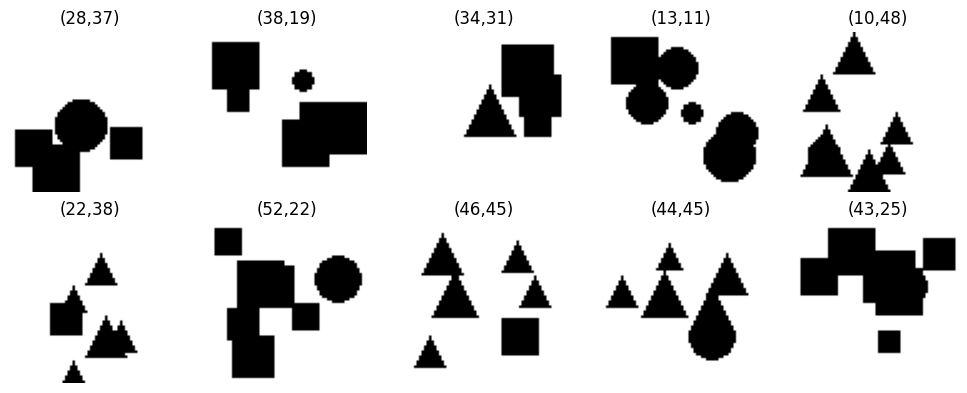

In [ ]:
# ============================================================
# 0. Imports & device
# ============================================================
import torch, random, math, numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# 1. Online dataset: 64×64, target = (cx,cy) ∈ [0,63]²  (float32)
# ============================================================
IMAGE = 64
SHAPES = ("circle", "square", "triangle")

def draw_shape(drawer, shape_type, center_x, center_y, radius):
    if shape_type == "circle":
        drawer.ellipse([center_x - radius, center_y - radius,
                        center_x + radius, center_y + radius], fill="black")
    elif shape_type == "square":
        drawer.rectangle([center_x - radius, center_y - radius,
                          center_x + radius, center_y + radius], fill="black")
    else:  # triangle
        drawer.polygon([
            (center_x, center_y - radius),
            (center_x - radius, center_y + radius),
            (center_x + radius, center_y + radius)
        ], fill="black")

class OddXYDataset(Dataset):
    """
    Generates images on-the-fly:
      * several random shapes of the same type
      * 1 additional shape of a different type
    Returns:
      * image (1×64×64 tensor, float32 normalized to [0,1])
      * label: float tensor [cx, cy] with center of the odd shape
    Arguments:
        num_samples             – total number of samples in the dataset
        same_shape_count_range – tuple (min, max), number of identical shapes
        shape_radius_range      – tuple (min_radius, max_radius) for shape size
    """
    def __init__(self,
                 num_samples,
                 same_shape_count_range=(3, 6),
                 shape_radius_range=(4, 10)):
        self.num_samples = num_samples
        self.same_shape_count_range = same_shape_count_range
        self.radius_min, self.radius_max = shape_radius_range

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        base_shape = random.choice(SHAPES)
        odd_shape = random.choice([s for s in SHAPES if s != base_shape])

        img = Image.new("L", (IMAGE, IMAGE), "white")
        drawer = ImageDraw.Draw(img)

        # draw identical shapes
        for _ in range(random.randint(*self.same_shape_count_range)):
            radius = random.randint(self.radius_min, self.radius_max)
            cx = random.randint(radius, IMAGE - radius - 1)
            cy = random.randint(radius, IMAGE - radius - 1)
            draw_shape(drawer, base_shape, cx, cy, radius)

        # draw the odd shape (with known center)
        radius = random.randint(self.radius_min, self.radius_max)
        cx = random.randint(radius, IMAGE - radius - 1)
        cy = random.randint(radius, IMAGE - radius - 1)
        draw_shape(drawer, odd_shape, cx, cy, radius)

        img_tensor = torch.tensor(np.array(img), dtype=torch.float32).unsqueeze(0) / 255.
        label_tensor = torch.tensor([float(cx), float(cy)], dtype=torch.float32)
        return img_tensor, label_tensor

def show_examples(num_examples=10):
    """
    Displays a grid of image samples from OddXYDataset using a DataLoader with batch_size=1.

    Args:
        num_examples (int): Number of examples to display.
    """
    dataset = OddXYDataset(num_samples=num_examples)
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

    num_columns = 5
    num_rows = math.ceil(num_examples / num_columns)

    fig, axes = plt.subplots(num_rows, num_columns, figsize=(num_columns * 2, num_rows * 2))

    for i, (image, label) in enumerate(dataloader):
        if i >= num_examples:
            break
        image_np = image.squeeze(0).squeeze(0).numpy()  # B=1,C=1,H,W --> H,W
        cx, cy = label.squeeze(0)                       # B=1,2       --> 2
        axes.flat[i].imshow(image_np, cmap="gray")
        axes.flat[i].set_title(f"({cx:.0f},{cy:.0f})")
        axes.flat[i].axis("off")

    for j in range(i + 1, num_rows * num_columns):
        axes.flat[j].axis("off")

    plt.tight_layout()
    plt.show()



show_examples()

### Helpful functions

In [ ]:
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on {device}")

pos_cnt = 16
positional_encoding_B = 1000

def sinusoid_positions(max_len=144, dim=16):
    pos = torch.arange(max_len, device=device).float().unsqueeze(1)
    i   = torch.arange(dim, device=device).float().unsqueeze(0)
    angle = pos / (positional_encoding_B ** (2 * (i//2) / dim))
    S = torch.zeros(max_len, dim, device=device)
    S[:, 0::2] = torch.sin(angle[:, 0::2])
    S[:, 1::2] = torch.cos(angle[:, 1::2])
    return S          #  SIZE: words, features  (constant matrix throuoght all computations)
import time


def train_model(net, epochs=1, lr=0.001, log_every=1):
    print(f"Working on {device}")
    net = net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)

    # Do regresji pozycji używamy Mean Squared Error
    criterion = torch.nn.MSELoss()

    train_rmse_history = []
    start_time = time.time()

    for epoch in range(epochs):
        net.train()
        set_seed(epoch)

        dataset = OddXYDataset(num_samples=25000)
        dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

        train_mse_sum = 0.0
        train_total = 0

        for batch_inputs, batch_labels in dataloader:
            batch_inputs = batch_inputs.to(device)          # [Batch_Size, 1, 64, 64]
            batch_labels = batch_labels.to(device).float()  # [Batch_Size, 2] - (cx, cy)

            optimizer.zero_grad()

            # (final_prediction, attention_weights)
            predictions, _, _ = net(batch_inputs)              # [Batch_Size, 2]

            loss = criterion(predictions, batch_labels)
            loss.backward()
            optimizer.step()

            train_mse_sum += loss.item() * batch_inputs.size(0)
            train_total += batch_inputs.size(0)

        # Wyliczamy średni błąd MSE, a następnie wyciągamy pierwiastek (RMSE)
        avg_train_mse = train_mse_sum / train_total
        avg_train_rmse = math.sqrt(avg_train_mse)

        train_rmse_history.append(avg_train_rmse)

        if epoch % log_every == 0:
            print(f"Epoch {epoch:02d} | Train RMSE: {avg_train_rmse:.2f} pixels")

    end_time = time.time()
    print(f"Elapsed time: {end_time - start_time:.2f} seconds")

    return train_rmse_history


def plot_rmse_curve(train_rmse_history):
    plt.figure(figsize=(8, 5))
    plt.plot(train_rmse_history, label="Train RMSE", color='blue', linewidth=2)

    # Wymóg projektu: wyraźne wskazanie poziomu 5.0 pikseli
    plt.axhline(y=5.0, color='red', linestyle='--', label="Target Level (5.0 px)")

    # Dodatkowo możemy dodać linię 3.0 dla poziomu BONUSOWEGO
    plt.axhline(y=3.0, color='green', linestyle=':', label="Bonus Level (3.0 px)")

    plt.title("Model Performance (RMSE) per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE (Pixels)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()


def compute_centers():
    centers = []
    for i in range(12):
        for j in range(12):
            cx = j * 4 + 10
            cy = i * 4 + 10
            centers.append((cx, cy))
    return torch.tensor(centers, dtype=torch.float32)   #(144, 2)

def soft_argmax(probs, centers):
    return (probs.unsqueeze(-1) * centers).sum(dim=1)  # (B, 2)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


Working on cuda


In [ ]:
import torch
import torch.nn as nn
import math

class ImageEmbeddingCNN(nn.Module):
    def __init__(self, out_channels=16):
        super().__init__()
        # single cnn layer
        self.conv = nn.Conv2d(in_channels=1, out_channels=out_channels, kernel_size=20, stride=4, padding=0)
        self.activation = nn.GELU()

    def forward(self, x):
        # input: [Batch_Size, 1, 64, 64]
        x = self.conv(x)          # [Batch_Size, 16, 12, 12]
        x = self.activation(x)    # [Batch_Size, 16, 12, 12]

        # flatten 2 last dimensions: 12 x 12 -> 144
        x = x.flatten(2)          # Rozmiar: [Batch_Size, 16, 144]

        # change dimensions order (Batch, Channels, Positions) -> (Batch, Positions, Channels)
        x = x.permute(0, 2, 1)    # Rozmiar: [Batch_Size, 144, 16]

        return x

class PositionalEncoding1D(nn.Module):
    def __init__(self, channels: int=16, max_len: int = 144, positional_encoding_B = 1000):
        super().__init__()

        # Tworzymy macierz na kodowania o rozmiarze [max_len, channels]
        pe = torch.zeros(max_len, channels)

        # Pozycje od 0 do 143 (kształt: [max_len, 1])
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        # Czynnik skalujący dla częstotliwości fal sinus/cosinus
        div_term = torch.exp(torch.arange(0, channels, 2).float() * (-math.log(positional_encoding_B) / channels))

        # Wypełniamy indeksy parzyste sinusem, a nieparzyste cosinusem
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Dodajemy wymiar batcha na początku -> [1, max_len, channels]
        # register_buffer sprawia, że PyTorch traktuje to jako stałą, a nie trenowalne wagi
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x ma rozmiar: [Batch_Size, 144, 16]
        # Po prostu DODAJEMY kodowanie pozycyjne do embeddingów z CNN
        x = x + self.pe[:, :x.size(1)]
        return x

class AttentionModule(nn.Module):
    def __init__(self, enc_dim=16, heads=1):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim=enc_dim, num_heads=heads, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(enc_dim, 64),
            nn.GELU(),
            nn.Linear(64, enc_dim)
        )
        self.norm1 = nn.LayerNorm(enc_dim)
        self.norm2 = nn.LayerNorm(enc_dim)

    def forward(self, x):
        attn_out, attn_weights = self.attention(x, x, x)
        x = self.norm1(x + attn_out)
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)
        return x, attn_weights


class AttentionOutputClassifier(nn.Module):
    def __init__(self, dim=16):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(dim, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.mlp(x).squeeze(-1)  # (B,144)


class OddNet(nn.Module):
    def __init__(self, embed_dim=16, heads=1):
        super().__init__()

        self.embedding = ImageEmbeddingCNN(out_channels=embed_dim)
        self.positional_enc = PositionalEncoding1D(channels=embed_dim, max_len=144)
        self.attention = AttentionModule(enc_dim=embed_dim, heads=heads)
        self.classifier = AttentionOutputClassifier(dim=embed_dim)

        # stałe centra pól recepcyjnych
        centers = compute_centers()
        self.register_buffer("centers", centers)

    def forward(self, x):
        x = self.embedding(x)                     # (B,144,16)
        x = self.positional_enc(x)                # (B,144,16)
        x, attn_weights = self.attention(x)       # (B,144,16), (B,144,144)

        logits = self.classifier(x)               # (B,144)
        probs = torch.softmax(logits, dim=1)      # (B,144)

        pred = soft_argmax(probs, self.centers)   # (B,2)

        return pred, attn_weights, probs


Working on cuda
Epoch 00 | Train RMSE: 13.33 pixels
Epoch 01 | Train RMSE: 12.88 pixels
Epoch 02 | Train RMSE: 12.47 pixels
Epoch 03 | Train RMSE: 11.97 pixels
Epoch 04 | Train RMSE: 10.99 pixels
Epoch 05 | Train RMSE: 10.54 pixels
Epoch 06 | Train RMSE: 10.23 pixels
Epoch 07 | Train RMSE: 10.11 pixels
Epoch 08 | Train RMSE: 9.93 pixels
Epoch 09 | Train RMSE: 9.86 pixels
Epoch 10 | Train RMSE: 9.76 pixels
Epoch 11 | Train RMSE: 9.67 pixels
Epoch 12 | Train RMSE: 9.48 pixels
Epoch 13 | Train RMSE: 9.35 pixels
Epoch 14 | Train RMSE: 9.14 pixels
Epoch 15 | Train RMSE: 8.93 pixels
Epoch 16 | Train RMSE: 8.86 pixels
Epoch 17 | Train RMSE: 8.68 pixels
Epoch 18 | Train RMSE: 8.47 pixels
Epoch 19 | Train RMSE: 8.30 pixels
Epoch 20 | Train RMSE: 8.30 pixels
Epoch 21 | Train RMSE: 7.98 pixels
Epoch 22 | Train RMSE: 7.85 pixels
Epoch 23 | Train RMSE: 7.78 pixels
Epoch 24 | Train RMSE: 7.64 pixels
Epoch 25 | Train RMSE: 7.49 pixels
Epoch 26 | Train RMSE: 7.37 pixels
Epoch 27 | Train RMSE: 7.28 pix

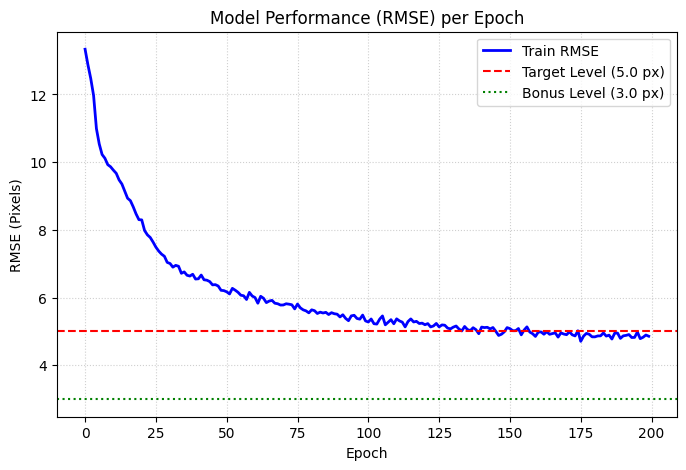

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)



net = OddNet(embed_dim=16, heads=2).to(device)

rmse_history = train_model(
    net,
    epochs=200,
    lr=0.001,
    log_every=1
)

plot_rmse_curve(rmse_history)

Working on cuda
Epoch 00 | Train RMSE: 13.29 pixels
Epoch 01 | Train RMSE: 12.46 pixels
Epoch 02 | Train RMSE: 11.84 pixels
Epoch 03 | Train RMSE: 10.92 pixels
Epoch 04 | Train RMSE: 10.29 pixels
Epoch 05 | Train RMSE: 9.74 pixels
Epoch 06 | Train RMSE: 9.61 pixels
Epoch 07 | Train RMSE: 9.40 pixels
Epoch 08 | Train RMSE: 8.92 pixels
Epoch 09 | Train RMSE: 8.51 pixels
Epoch 10 | Train RMSE: 8.13 pixels
Epoch 11 | Train RMSE: 7.54 pixels
Epoch 12 | Train RMSE: 7.27 pixels
Epoch 13 | Train RMSE: 7.10 pixels
Epoch 14 | Train RMSE: 7.04 pixels
Epoch 15 | Train RMSE: 6.67 pixels
Epoch 16 | Train RMSE: 6.59 pixels
Epoch 17 | Train RMSE: 6.53 pixels
Epoch 18 | Train RMSE: 6.35 pixels
Epoch 19 | Train RMSE: 6.15 pixels
Epoch 20 | Train RMSE: 6.34 pixels
Epoch 21 | Train RMSE: 6.07 pixels
Epoch 22 | Train RMSE: 5.98 pixels
Epoch 23 | Train RMSE: 5.98 pixels
Epoch 24 | Train RMSE: 6.00 pixels
Epoch 25 | Train RMSE: 5.70 pixels
Epoch 26 | Train RMSE: 5.71 pixels
Epoch 27 | Train RMSE: 5.80 pixels

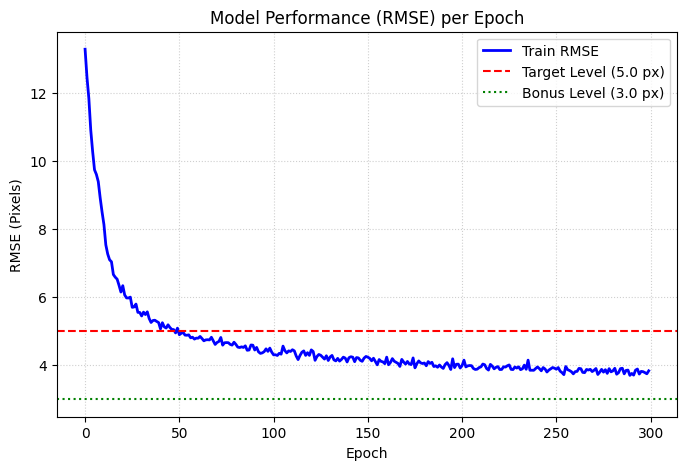

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)


net = OddNet(embed_dim=32, heads=4).to(device)

rmse_history = train_model(
    net,
    epochs=300,
    lr=0.001,
    log_every=1
)

plot_rmse_curve(rmse_history)